In [1]:
import pandas as pd
import dill

import matplotlib.pyplot as plt
import seaborn as sns

<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Function for Loading the Preprocessor and the Trained Model</h2>

In [2]:
# Function to load the model and preprocessor
def load_model_and_preprocessor(preprocessor_path: str , model_path: str):
    """
    Loading the preprocessor and the best model from saved files.
    """
    # Load the preprocessor
    with open(preprocessor_path, 'rb') as preprocessor_file:
        preprocessor = dill.load(preprocessor_file)
    
    # Loading the saved model
    with open(model_path, 'rb') as model_file:
        best_model = dill.load(model_file)

   
    return  preprocessor , best_model

<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Function for Fitting the Preprocessor on New Data and Transforming It</h2>

In [3]:
# Function to preprocess new data
def preprocess_new_data(df: pd.DataFrame, preprocessor) -> pd.DataFrame:
    
    """
    Applying the same preprocessing to the new data.
    """
    preprocessed_features = preprocessor.transform(df)
    
    return preprocessed_features

<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Defining the Prediction Function for Unseen Data</h2>


In [4]:
# Function to make predictions on new data
def make_predictions(new_data: pd.DataFrame, preprocessor , best_model) -> pd.DataFrame:
    """
    Predict the target variable on new data and return the results.
    """
    new_data_processed = preprocess_new_data(new_data, preprocessor)  # Using the Above defined function to get the preprocessed data
    
    # Predicting  using the best model
    predictions = best_model.predict(new_data_processed)
    
    return predictions

In [5]:
model_path = "..\Artifacts\Model\Best_Model.pkl"
preprocessor_path = "..\Artifacts\Preprocessor\preprocessor_object.pkl"

In [6]:
 # Load the model and preprocessor
preprocessor , best_model = load_model_and_preprocessor(preprocessor_path , model_path)

In [7]:
preprocessor

ColumnTransformer(transformers=[('numeric_pipeline',
                                 Pipeline(steps=[('scaler',
                                                  StandardScaler(with_mean=False))]),
                                 ['CreditScore', 'Age', 'Tenure', 'Balance',
                                  'EstimatedSalary']),
                                ('categorical_pipeline',
                                 Pipeline(steps=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore')),
                                                 ('scaler',
                                                  StandardScaler(with_mean=False))]),
                                 ['Geography', 'Gender']),
                                ('type_casting_pipeline',
                                 Pipeline(steps=[('type_casting',
                                                  FunctionTransformer(func=<function convert_object_to_int at 0x0000018AEBFC4E50>)),
                                                 ('scaler',
                                                  StandardScaler(with_mean=False))]),
                                 ['NumOfProducts', 'HasCrCard',
                                  'IsActiveMember'])])

In [8]:
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

Unseen_dataset:

In [9]:
test_data = pd.read_csv("../Artifacts/Datasets/test.csv")
test_data.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,585.0,France,Male,36.0,7,0.00,2,1,0,94283.09,0
1,525.0,Germany,Male,33.0,4,131023.76,2,0,0,55072.93,0
2,557.0,Spain,Female,40.0,4,0.00,2,0,1,105433.53,0
3,639.0,Spain,Male,34.0,5,139393.19,2,0,0,33950.08,0
4,640.0,Spain,Female,34.0,3,77826.80,1,1,1,168544.85,0


<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Making Predictions on the Incoming Data</h2>


In [10]:
df_new_data = test_data.drop(columns=['Exited'],axis=1)
df_new_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,585.0,France,Male,36.0,7,0.00,2,1,0,94283.09
1,525.0,Germany,Male,33.0,4,131023.76,2,0,0,55072.93
2,557.0,Spain,Female,40.0,4,0.00,2,0,1,105433.53
3,639.0,Spain,Male,34.0,5,139393.19,2,0,0,33950.08
4,640.0,Spain,Female,34.0,3,77826.80,1,1,1,168544.85


In [11]:
# Predict on the new dataset
new_predictions = make_predictions(df_new_data , preprocessor, best_model)
print("Predictions on new data:",new_predictions)

Predictions on new data: [0 0 0 ... 1 0 0]


In [12]:
predicted_values = pd.DataFrame(new_predictions, columns=['Exited'])
predicted_values

,Exited
0,0
1,0
2,0
3,0
4,0
...,...
1995,0
1996,0
1997,1
1998,0


---------

In [13]:
predicted_values[predicted_values['Exited']==0]

,Exited
0,0
1,0
2,0
3,0
4,0
...,...
1994,0
1995,0
1996,0
1998,0


In [14]:
predicted_values[predicted_values['Exited']==1]

,Exited
8,1
10,1
18,1
20,1
31,1
...,...
1975,1
1982,1
1983,1
1989,1


<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Comparing Actual and Predicted Values</h2>

In [15]:
Actual_data = test_data['Exited']
Predicted_data = predicted_values['Exited']

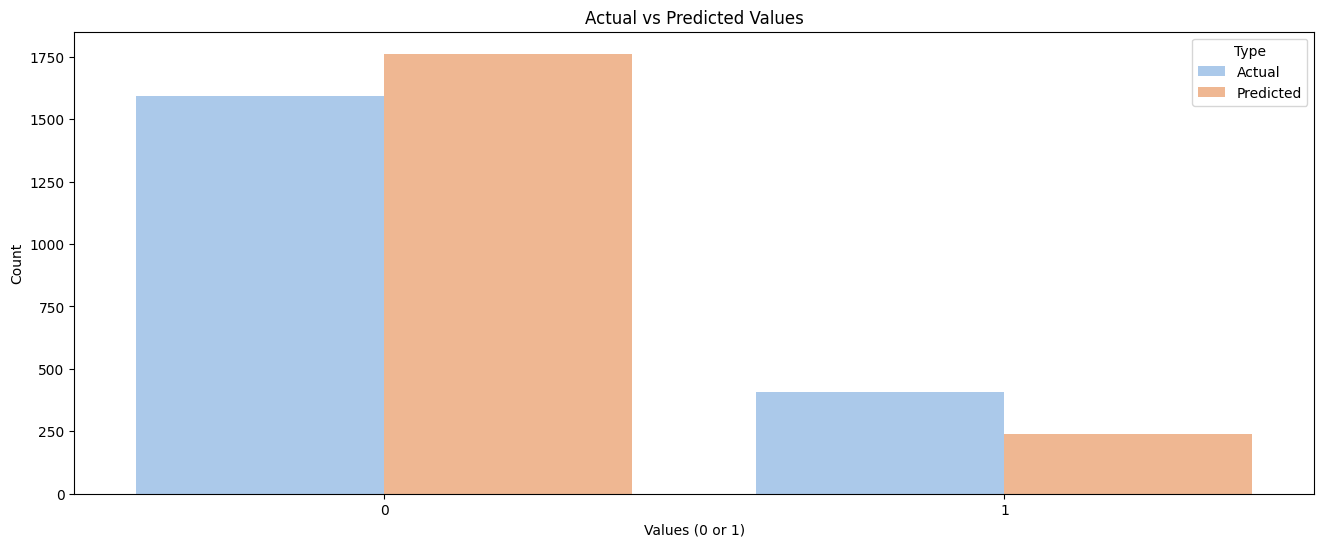

In [16]:

df_comparison = pd.DataFrame({
    'Actual': Actual_data,
    'Predicted': Predicted_data
})


df_melted = pd.melt(df_comparison, value_vars=['Actual', 'Predicted'], var_name='Type', value_name='Value')

# Plot using Seaborn
plt.figure(figsize=(16, 6))
sns.countplot(x='Value', hue='Type', data=df_melted, palette='pastel')
plt.title('Actual vs Predicted Values')
plt.xlabel('Values (0 or 1)')
plt.ylabel('Count')
plt.show()


### Customer Retention Rate (CRR) - Note

The **Customer Retention Rate (CRR)** measures the percentage of customers expected to stay with the service over a given period. In machine learning applications, retention is estimated based on the model's prediction of customer churn. The formula used to calculate CRR from the predictions is:

### Main Formula

```
Estimated CRR = (Predicted Non-Churned / Total Predictions) * 100
```

Where:  
- **Predicted Non-Churned** = Number of customers predicted to stay (Exited = 0)  
- **Total Predictions** = Total number of customers predicted (both churned and non-churned)

This formula helps businesses estimate how well they are retaining customers based on model predictions.


In [17]:
# Code to Estimate Retention Rate

retained = (predicted_values['Exited'] == 0).sum()
total = len(predicted_values)
retention_rate = (retained / total) * 100

print(f"Estimated Customer Retention Rate: {retention_rate:.2f}%")

Estimated Customer Retention Rate: 88.10%


<h2 style="font-family: 'Brush Script MT', cursive; color: goldenrod;">Comparing Actual vs Predicted Customer Retention and Churn</h2>


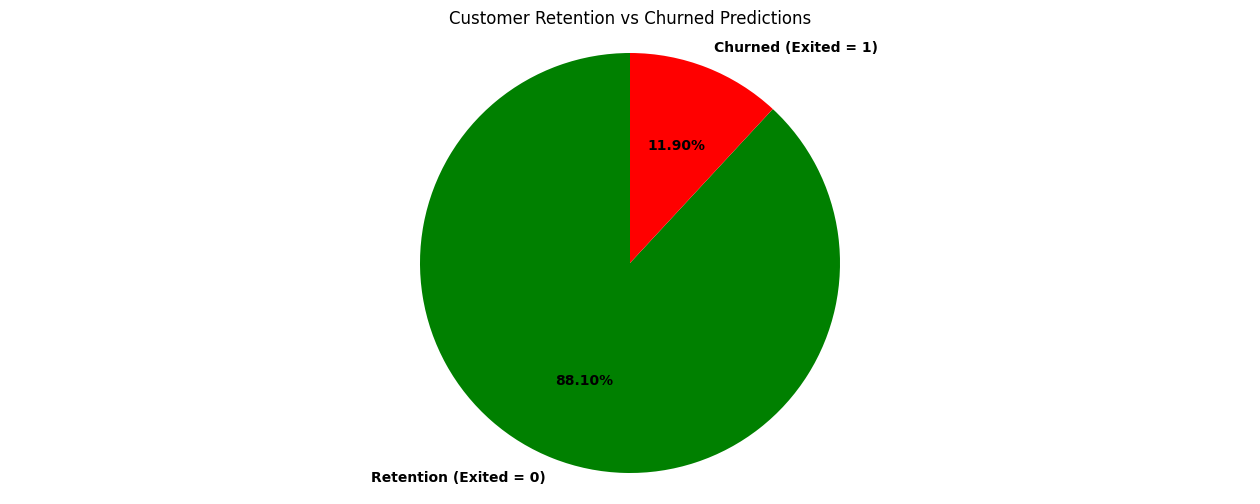

In [18]:
# Filter values where Exited == 0 (Non-Churned/Retained) and Exited == 1 (Churned)
retained = predicted_values[predicted_values['Exited'] == 0]
churned = predicted_values[predicted_values['Exited'] == 1]

# Get the count of each value for Pie chart
retention_counts = [len(retained), len(churned)]  # Count of retained and churned customers

# Labels for the Pie chart
labels = ['Retention (Exited = 0)', 'Churned (Exited = 1)']

# Custom colors: Green for Retention and Red for Churn
colors = ['green', 'red']

# Create the Pie chart
plt.figure(figsize=(16,6))
plt.pie(retention_counts, labels=labels, autopct='%1.2f%%', startangle=90, colors=colors, textprops={'weight': 'bold'})

# Title and equal aspect ratio to ensure it's circular
plt.title('Customer Retention vs Churned Predictions')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


-------